In [16]:
import pandas as pd
from scipy.fft import rfft, rfftfreq
import numpy as np

In [ ]:
# load the data from the CSV file
data_file = 'mpu6500_data_2000Hz_2MBaud.csv'
data = pd.read_csv(data_file)
data

,pc_time,packet_counter,arduino_time_us,ax_raw,ay_raw,az_raw,gx_raw,gy_raw,gz_raw
0,1.777180e+09,0,710204,-496,142,8740,-92,-2422,-66
1,1.777180e+09,0,711200,-462,112,8698,-92,-2491,-57
2,1.777180e+09,0,712200,-476,134,8682,-92,-2563,-46
3,1.777180e+09,0,713200,-508,124,8720,-92,-2639,-36
4,1.777180e+09,0,714200,-516,124,8740,-98,-2712,-29
...,...,...,...,...,...,...,...,...,...
11515,1.777180e+09,359,12225200,-484,190,8186,16,109,12
11516,1.777180e+09,359,12226200,-496,190,8182,14,108,10
11517,1.777180e+09,359,12227200,-520,174,8152,13,107,6
11518,1.777180e+09,359,12228200,-538,188,8150,16,106,4


In [18]:
# get avg frequency of samples
time_between_samples = data['arduino_time_us'].diff().dropna()
avg_freq = 1 / (10 ** -6 * time_between_samples.mean())
avg_freq

np.float64(1000.0)

In [ ]:
list(data['arduino_time_us'].diff())[0:50]

[nan,
 996.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1004.0,
 996.0,
 1004.0,
 996.0,
 1004.0,
 996.0,
 1004.0,
 996.0,
 1004.0,
 996.0,
 1004.0,
 996.0,
 1004.0,
 996.0,
 1000.0,
 1000.0,
 1008.0,
 1000.0,
 992.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1004.0,
 996.0,
 9216.0,
 100.0,
 116.0,
 100.0,
 100.0,
 100.0,
 100.0,
 100.0,
 100.0,
 100.0,
 868.0,
 1004.0,
 996.0,
 1004.0,
 996.0,
 1004.0,
 996.0,
 1004.0,
 996.0,
 1004.0,
 996.0,
 1004.0,
 996.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1004.0,
 996.0,
 9232.0,
 100.0,
 100.0,
 100.0,
 100.0,
 100.0,
 100.0,
 100.0,
 100.0,
 100.0,
 868.0,
 1000.0,
 1004.0,
 996.0,
 1004.0,
 996.0,
 1004.0,
 996.0,
 1004.0,
 996.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1000.0,
 1004.0,
 996.0,
 1004.0,
 996.0,
 1004.0,
 996.0,
 1004.0,
 9216.0,
 100.0,
 100.0,
 100.0,
 100.0,
 100.0,
 100.0,
 112.0,
 104.0,
 100.0,
 868.0,
 1000.0,
 1004.0,
 1000.0,
 992.0,
 1004.0,
 996.0,
 1004.0,
 996.0,
 1004.0,
 996.0,
 1004.0,

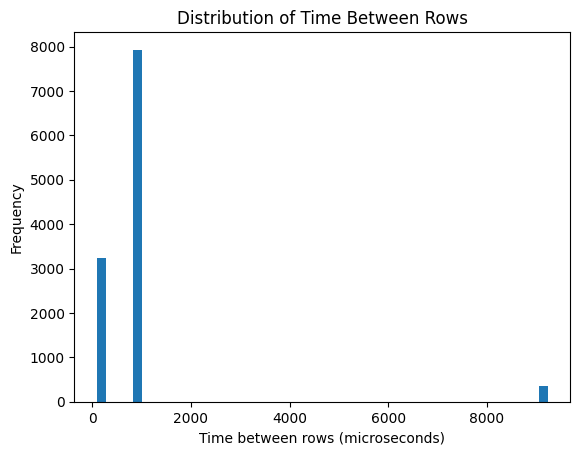

In [19]:
# plot the distribution of t_us between rows
import matplotlib.pyplot as plt
plt.hist(data['arduino_time_us'].diff().dropna(), bins=50)
plt.xlabel('Time between rows (microseconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Time Between Rows')
plt.show()

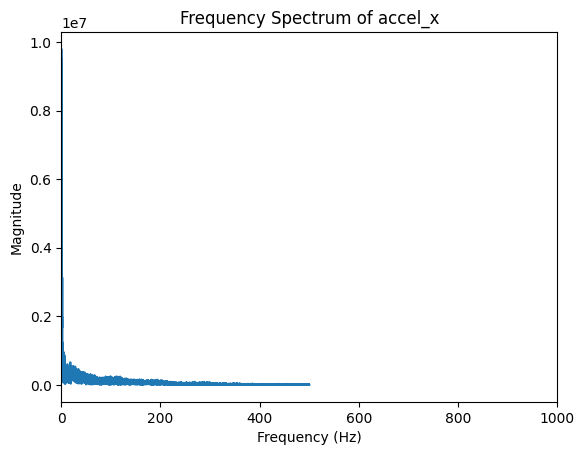

In [20]:
# perform frequency analysis on accel data
# Number of samples
N = len(data)
# Sample spacing
T = 1 / avg_freq
# Perform FFT on accel_x
yf = rfft(data['ax_raw'])
xf = rfftfreq(N, T)
plt.plot(xf, np.abs(yf))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Frequency Spectrum of accel_x')
plt.xlim(0, 1000)  # Limit x-axis to 1000 Hz
plt.show()